Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Epoch 1/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 21s 433ms/step - accuracy: 0.5450 - loss: 0.7806 - val_accuracy: 0.7908 - val_loss: 0.4998
Epoch 2/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.8068 - loss: 0.4750 - val_accuracy: 0.8478 - val_loss: 0.3795
Epoch 3/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.8560 - loss: 0.3583 - val_accuracy: 0.9022 - val_loss: 0.3151
Epoch 4/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.9129 - loss: 0.2878 - val_accuracy: 0.9185 - val_loss: 0.2576
Epoch 5/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.9341 - loss: 0.2164 - val_accuracy: 0.9266 - val_loss: 0.2362
Epoch 6/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.9662 - loss: 0.1606 - val_accuracy: 0.9620 - val_loss: 0.1575
Epoch 7/10
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - accuracy: 0.9974 - loss: 0.0912 - val_accuracy: 0.9728

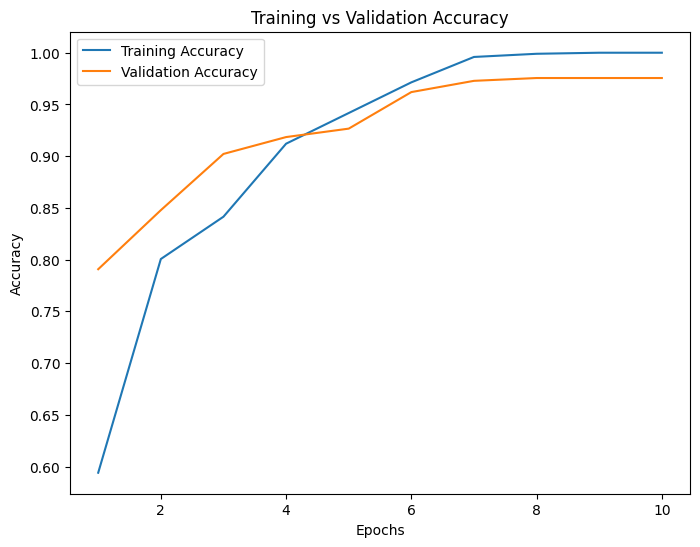

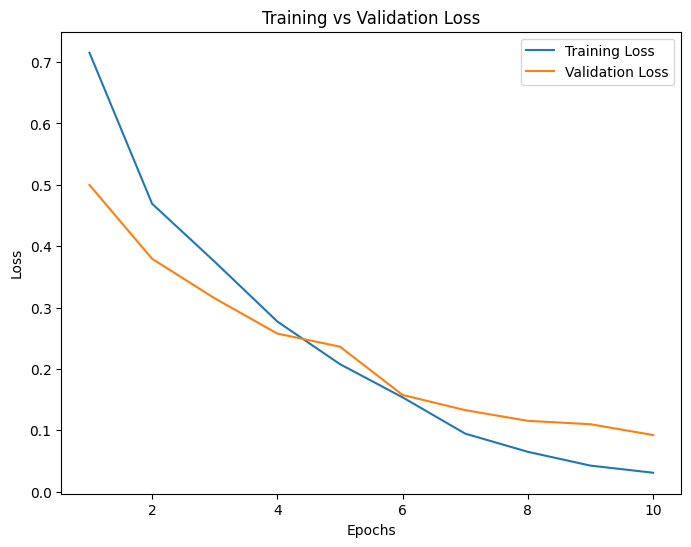

✅ Model saved at: /content/drive/MyDrive/image_identifier_model.h5


In [ ]:

# STEP 1: Mount Google Drive

from google.colab import drive
drive.mount('/content/drive')

# Paths to dataset
train_dir = "/content/drive/MyDrive/dataset_split/train"
val_dir   = "/content/drive/MyDrive/dataset_split/val"


# STEP 2: Preprocessing

import os
from PIL import Image
import numpy as np

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Preprocess a single image (Resize → Array → Normalize)
def preprocess_image(image_path):
    img = Image.open(image_path).convert('RGB')   # Ensure 3 channels
    img = img.resize(IMG_SIZE)                    # Resize
    arr = np.array(img) / 255.0                   # To array + Normalize
    return arr

# Load dataset from folders (real=1, ai=0)
def load_dataset(base_dir, classes):
    images, labels = [], []
    for cls, label in classes:
        folder = os.path.join(base_dir, cls)
        for fname in os.listdir(folder):
            try:
                arr = preprocess_image(os.path.join(folder, fname))
                images.append(arr)
                labels.append(label)
            except:
                pass  # skip corrupted images
    return np.array(images), np.array(labels)

# Batching (group images into mini-batches)
def create_batches(images, labels, batch_size=BATCH_SIZE):
    num_batches = len(images) // batch_size
    for i in range(num_batches):
        yield (images[i*batch_size:(i+1)*batch_size],
               labels[i*batch_size:(i+1)*batch_size])

# STEP 3: Build and Train Model

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

# Load training and validation sets
train_images, train_labels = load_dataset(train_dir, [('real',1), ('ai',0)])
val_images, val_labels = load_dataset(val_dir, [('real',1), ('ai',0)])

# 1. Load MobileNetV2 (pretrained, no top layer)
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))
base_model.trainable = False   # Freeze pretrained layers

# 2. Add custom classification layers
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),    layers.Dense(1, activation='sigmoid')   # Output: 0 (AI) / 1 (Real)
])

# 3. Compile model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# 4. Train model
history = model.fit(train_images, train_labels,
                    validation_data=(val_images, val_labels),
                    epochs=10,
                    batch_size=32)

# -----------------------------
# STEP 4: Evaluate and Predict
# -----------------------------

# 1. Evaluate model performance
loss, acc = model.evaluate(val_images, val_labels, verbose=0)
print(f"Validation Accuracy: {acc*100:.2f}%")
print(f"Validation Loss: {loss:.4f}")

# 2. Make prediction on one new image
def predict_image(image_path):
    img = preprocess_image(image_path)        # Resize, array, normalize (Step 2)
    img = np.expand_dims(img, axis=0)         # Add batch dimension (1,224,224,3)
    pred = model.predict(img)[0][0]           # Prediction probability
    if pred > 0.5:
        return "Real Image"
    else:
        return "AI-Generated Image"

# -----------------------------
# STEP 5: Tranining Graphs
# -----------------------------

import matplotlib.pyplot as plt

# Get accuracy and loss from history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(1, len(acc) + 1)

# Plot Accuracy
plt.figure(figsize=(8, 6))
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

# Plot Loss
plt.figure(figsize=(8, 6))
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()



